# Project 1 — FIR Filter for Signal Denoising

## What this project does
A clean sine wave at 50 Hz is buried in Gaussian noise.
A FIR low-pass filter is designed and applied to recover the original signal.

## Concepts covered
- Signal generation in Python
- Adding AWGN (Additive White Gaussian Noise)
- FIR filter design using SciPy
- Time domain and frequency domain analysis using FFT

## Tools used
- NumPy, SciPy, Matplotlib

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp

In [4]:
fs = 1000        # sampling frequency in Hz
T = 1.0          # signal duration in seconds
t = np.arange(0, T, 1/fs)
# np.arange(start, stop, step): creates evenly spaced time values

f = 50           # sine wave frequency in Hz
clean = np.sin(2 * np.pi * f * t)
# np.sin(): computes sine for each value in t
# 2 * np.pi * f converts frequency from Hz to radians per second

noise = np.random.randn(len(t)) * 0.5
# np.random.randn(n): generates n Gaussian random numbers (mean=0, std=1)
# * 0.5: scales noise amplitude

noisy = clean + noise

print(f"Signal length: {len(t)} samples")
print(f"Signal frequency: {f} Hz")
print(f"Noise amplitude: 0.5")

Signal length: 1000 samples
Signal frequency: 50 Hz
Noise amplitude: 0.5


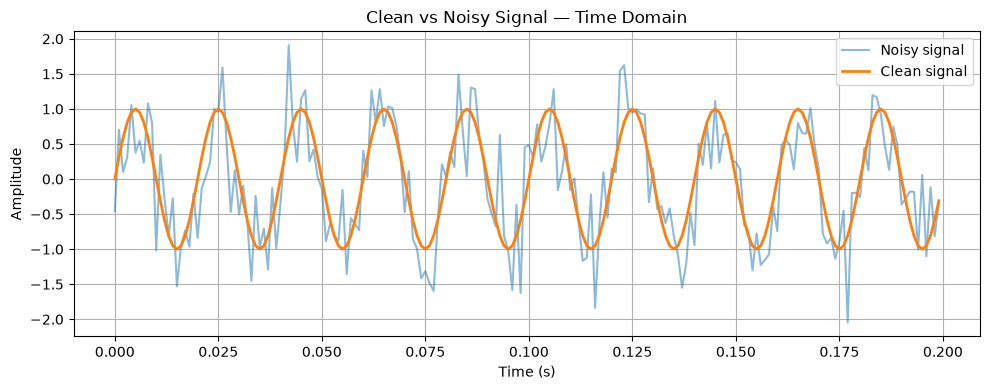

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(t[:200], noisy[:200], label="Noisy signal", alpha=0.5)
plt.plot(t[:200], clean[:200], label="Clean signal", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Clean vs Noisy Signal — Time Domain")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
cutoff = 100     # cutoff frequency in Hz — everything above this is removed
numtaps = 51     # number of filter coefficients — more = sharper cutoff

h = sp.firwin(numtaps, cutoff, fs=fs)
# sp.firwin(): designs a FIR low-pass filter
# numtaps: length of the filter
# cutoff: frequency in Hz where filtering begins
# fs: sampling rate so the function can scale correctly

filtered = sp.lfilter(h, 1.0, noisy)
# sp.lfilter(): applies the filter to the noisy signal
# h: filter coefficients
# 1.0: denominator — always 1.0 for FIR filters
# noisy: input signal

print(f"Filter cutoff: {cutoff} Hz")
print(f"Filter taps: {numtaps}")

Filter cutoff: 100 Hz
Filter taps: 51


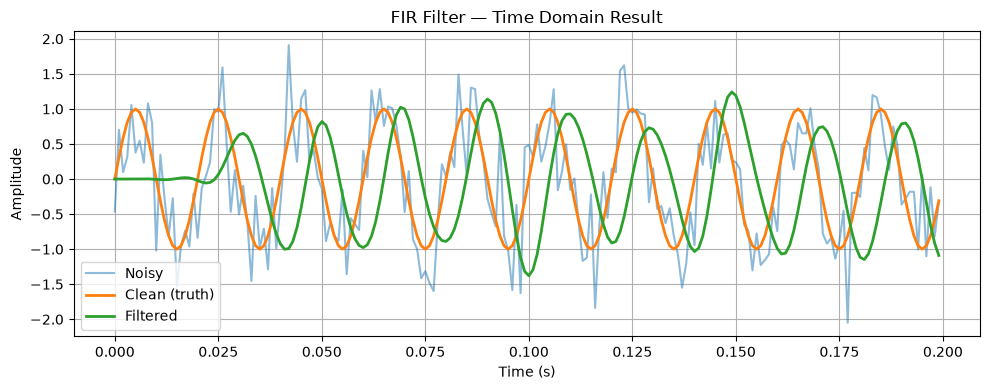

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(t[:200], noisy[:200],    label="Noisy",         alpha=0.5)
plt.plot(t[:200], clean[:200],    label="Clean (truth)",  linewidth=2)
plt.plot(t[:200], filtered[:200], label="Filtered",       linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("FIR Filter — Time Domain Result")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

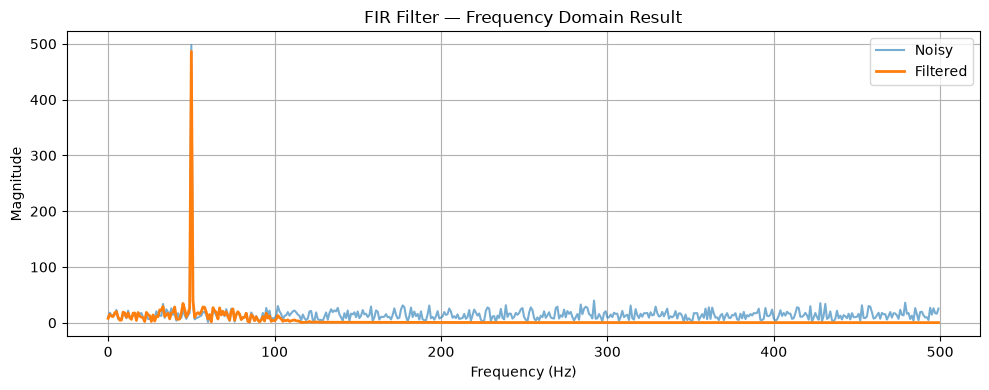

In [8]:
N = len(t)
half = N // 2
# // integer division: gives exactly half the array length as a whole number

freqs = np.fft.fftfreq(N, 1/fs)[:half]
# np.fft.fftfreq(): generates frequency axis for FFT output
# N: number of samples
# 1/fs: sample spacing in seconds

fft_noisy    = np.abs(np.fft.fft(noisy))[:half]
fft_filtered = np.abs(np.fft.fft(filtered))[:half]
# np.fft.fft(): computes Fast Fourier Transform
# np.abs(): converts complex FFT output to magnitude values

plt.figure(figsize=(10, 4))
plt.plot(freqs, fft_noisy,    label="Noisy",    alpha=0.6)
plt.plot(freqs, fft_filtered, label="Filtered", linewidth=2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FIR Filter — Frequency Domain Result")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Key observations

- The FIR filter successfully recovers the 50 Hz signal buried in noise
- In the frequency domain, the noise floor is significantly reduced above the cutoff frequency
- Higher numtaps = sharper cutoff = better noise rejection
- Cutoff must be set above the signal frequency to avoid distorting the signal

## What I learned
- How noise spreads energy across all frequencies (noise floor)
- How a low-pass filter selectively removes high-frequency noise
- The trade-off between filter sharpness (numtaps) and computation cost